
# 1. Libraries


In [1]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import os


# 2. Data Path and Loading


In [2]:
DATA_DIR = Path("../data/eye_tracking")

In [3]:
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(csv_files[:3])

[WindowsPath('../data/eye_tracking/01_ET_Data_2026-02-19.csv'), WindowsPath('../data/eye_tracking/02_ET_Data_2026-03-10.csv')]


In [4]:
file_path = csv_files[1]  # Christian on-boarding

df = pd.read_csv(file_path, low_memory=False)

# extract participant_id from filename
participant_id = file_path.name[:2]
df["participant_id"] = participant_id

print(df.shape)

(384510, 61)


In [5]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
0,1000325398422099900,1773140944969,41.12195,2.000000,525251,0.293504,Valid,0.012164,-0.266522,0.963752,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
1,1000325398427100300,1773140944973,41.12195,2.000000,525252,0.315788,Valid,0.013124,-0.265512,0.964018,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
2,1000325398432112600,1773140944973,41.12195,2.000000,525253,0.354264,Valid,0.014052,-0.264599,0.964256,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
3,1000325398437113000,1773140944973,41.12195,2.000000,525254,0.441358,Valid,0.014769,-0.263616,0.964515,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
4,1000325398442101200,1773140944973,41.12195,2.000000,525255,0.473352,Valid,0.015610,-0.262661,0.964762,...,0,0,-1.06,0.00,0.93,0.0,0.000000,0.0,1.000000,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384505,1000328184386556900,1773143730444,1607.74300,1.276645,1082229,1.000000,Valid,-0.036495,0.168651,0.985000,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384506,1000328184391558700,1773143730454,1607.75400,1.277654,1082230,0.998679,Valid,-0.036406,0.169091,0.984928,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384507,1000328184396558500,1773143730454,1607.75400,1.278499,1082231,0.993781,Valid,-0.036322,0.169536,0.984854,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02
384508,1000328184401558700,1773143730465,1607.76500,1.277999,1082232,0.982768,Valid,-0.036273,0.170024,0.984772,...,6,0,3.25,1.52,-0.11,0.0,-0.707107,0.0,0.707107,02


# Estimate Sampling Rate

In [6]:
t = pd.to_numeric(df["gaze_capture_time"], errors="coerce")
dt_ns = t.diff().dropna()

median_dt_ns = dt_ns.median()
sampling_rate_hz = 1e9 / median_dt_ns

print(f"Estimated sampling rate: {sampling_rate_hz:.2f} Hz")
print(f"Median sample interval: {median_dt_ns:.0f} ns")
print(f"Median sample interval: {median_dt_ns / 1e6:.3f} ms")

Estimated sampling rate: 199.98 Hz
Median sample interval: 5000600 ns
Median sample interval: 5.001 ms


# Preprocessing function

In [7]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess eye-tracking data for analysis.

    Steps:

       - remove training models (TM) and NaN
 ......
    """

    df = df.copy()

    mask = (
        df["model_name"].notna() &
        (~df["model_name"].str.contains("TM", na=False))
    )
    df = df.loc[mask].copy()


    return df

In [8]:
df_clean = cleaning_function(df)

In [9]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02


In [10]:
df_clean["condition_number"].value_counts()

condition_number
2    69494
1    68479
3    64996
Name: count, dtype: int64

In [11]:
df_clean["trial_number"].value_counts()

trial_number
6    47551
5    45229
3    33343
2    33159
4    24764
1    18923
Name: count, dtype: int64

In [12]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,1,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,6,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02


# Time Function

In [13]:
def add_time_per_model(df, time_col: str = "gaze_capture_time"):
    """
    Add time_ms per model_name, respecting experiment order.

    Sorting:
    condition_number → trial_number → time

    Assumes:
    - time_col is in nanoseconds
    - df contains: model_name, condition_number, trial_number
    """

    df = df.copy()

    # correct ordering of experiment
    df = df.sort_values(["condition_number", "trial_number", time_col])

    # compute relative time per model
    t0 = df.groupby("model_name")[time_col].transform("first")

    df["time_ms"] = (df[time_col] - t0) / 1_000_000.0

    return df

In [14]:
df_clean = add_time_per_model(df_clean, time_col="gaze_capture_time")

In [15]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


In [16]:
df_clean["right_status"].value_counts()

right_status
Tracked        187907
Compensated     11978
Invalid          2097
Visible           987
Name: count, dtype: int64

In [17]:
df_clean["left_status"].value_counts()

left_status
Tracked        192165
Compensated      7740
Invalid          2471
Visible           593
Name: count, dtype: int64

In [18]:
df_clean["model_name"].value_counts()

model_name
C3M5F    21653
C3M4A    21123
C3M2A    19455
C3M1F    19130
C2M2A    18793
C2M1F    15074
C3M3F    13347
C3M6A    12824
C2M3F    10647
C2M4A    10276
C2M6A     8234
C2M5F     7960
C1M4A     4651
C1M2A     4275
C1M5F     4274
C1M3F     4001
C1M6A     3706
C1M1F     3546
Name: count, dtype: int64

In [19]:
df_clean["model_name"].isna().sum()

np.int64(0)

In [20]:
df_clean["model_name"].eq("").sum()

np.int64(0)

In [21]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,participant_id,time_ms
44844,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,0.0000
44845,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,5.0002
44846,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,9.9972
44847,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,14.9980
44848,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0,3.25,1.520,-0.11,0.0,-0.707107,0.0,0.707107,02,19.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97592.3892
381612,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97597.3875
381613,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97602.3869
381614,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,0,0.75,0.975,-0.70,0.0,0.000000,0.0,1.000000,02,97607.3863


In [22]:
df_clean["left_origin_x"].value_counts()

left_origin_x
-0.033577    200498
 0.000000      2471
Name: count, dtype: int64

In [23]:
df_clean["right_origin_x"].value_counts()

right_origin_x
0.033577    200872
0.000000      2097
Name: count, dtype: int64

In [24]:
df_clean["left_origin_y"].value_counts()

left_origin_y
0    202969
Name: count, dtype: int64

In [25]:
df_clean.describe()

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,gaze_forward_x,gaze_forward_y,gaze_forward_z,gaze_origin_x,...,trial_number,model_visibility_state,object_position_x,object_position_y,object_position_z,object_rotation_x,object_rotation_y,object_rotation_z,object_rotation_w,time_ms
count,2.029690e+05,2.029690e+05,202969.000000,202969.000000,2.029690e+05,202969.000000,202969.000000,202969.000000,202969.000000,202969.0,...,202969.000000,202969.000000,202969.000000,202969.000000,202969.000000,202969.000000,202969.000000,202969.000000,202969.000000,202969.000000
mean,1.000327e+18,1.773143e+12,824.135605,0.771619,8.433074e+05,0.468695,-0.001710,0.048812,0.980607,0.0,...,3.920682,0.181722,0.615122,0.938047,-0.018271,0.372491,0.163522,-0.126552,0.530378,38572.345796
std,8.292339e+11,8.292344e+05,420.738073,0.412465,1.657828e+05,0.381110,0.152864,0.109258,0.026824,0.0,...,1.676455,0.385616,0.627174,0.348866,1.170182,0.358865,0.408983,0.336490,0.357660,28181.264383
min,1.000326e+18,1.773141e+12,277.420200,0.010000,5.844920e+05,0.000000,-0.908439,-0.882694,0.082043,0.0,...,1.000000,0.000000,-2.570000,0.000000,-3.000000,-0.709250,-0.991445,-0.785682,-0.923880,0.000000
25%,1.000326e+18,1.773142e+12,475.095700,0.502500,6.637330e+05,0.000000,-0.074862,-0.026392,0.977123,0.0,...,2.000000,0.000000,0.216729,0.971702,-0.700000,0.000000,-0.002813,-0.419494,0.498705,14625.854500
50%,1.000327e+18,1.773143e+12,663.106300,0.636151,8.590550e+05,0.527691,-0.005596,0.056271,0.989185,0.0,...,4.000000,0.000000,0.722372,0.998500,-0.000003,0.501576,0.066870,-0.000012,0.653281,33142.205600
75%,1.000328e+18,1.773143e+12,1289.720000,0.880718,1.018552e+06,0.824026,0.073443,0.129761,0.995709,0.0,...,5.000000,0.000000,1.000422,1.077506,1.018112,0.667766,0.500933,0.000000,0.707107,58642.446200
max,1.000328e+18,1.773144e+12,1593.000000,2.000000,1.079282e+06,1.000000,0.676390,0.781415,1.000000,0.0,...,6.000000,1.000000,3.250000,1.520000,3.000000,0.898266,1.000000,0.808685,1.000000,109967.937100


In [26]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202969 entries, 44844 to 381615
Data columns (total 62 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   gaze_capture_time                 202969 non-null  int64  
 1   raw_timestamp                     202969 non-null  int64  
 2   relative_to_unix_epoch_timestamp  202969 non-null  float64
 3   focus_distance                    202969 non-null  float64
 4   frame_number                      202969 non-null  int64  
 5   stability                         202969 non-null  float64
 6   status                            202969 non-null  object 
 7   gaze_forward_x                    202969 non-null  float64
 8   gaze_forward_y                    202969 non-null  float64
 9   gaze_forward_z                    202969 non-null  float64
 10  gaze_origin_x                     202969 non-null  int64  
 11  gaze_origin_y                     202969 non-null  in

# 8. Define Valid Samples and Interpolation

In [27]:
FORWARD_COLS = ["gaze_forward_x", "gaze_forward_y", "gaze_forward_z"]
CLEAN_FORWARD_COLS = ["clean_gaze_forward_x", "clean_gaze_forward_y", "clean_gaze_forward_z"]


def good_status(left_status: pd.Series, right_status: pd.Series) -> np.ndarray:
    l = left_status.astype(str).str.lower().str.strip()
    r = right_status.astype(str).str.lower().str.strip()

    allowed_pairs = {
        ("tracked", "tracked"),
        ("tracked", "compensated"),
        ("compensated", "tracked"),
        ("compensated", "compensated")
    }

    good = pd.Series(
        [(ls, rs) in allowed_pairs for ls, rs in zip(l, r)],
        index=left_status.index
    )

    return good.to_numpy(dtype=bool)

def find_runs(mask: np.ndarray):
    mask = np.asarray(mask, dtype=bool)
    idx = np.flatnonzero(mask)

    if len(idx) == 0:
        return []

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k

    runs.append((start, prev))
    return runs

def expand_runs(runs, n, pad=2):
    """
    Expand each run by `pad` samples on both sides,
    then merge overlaps.
    """
    if len(runs) == 0:
        return []

    expanded = []
    for a, b in runs:
        aa = max(0, a - pad)
        bb = min(n - 1, b + pad)
        expanded.append((aa, bb))

    expanded.sort()
    merged = [expanded[0]]

    for a, b in expanded[1:]:
        prev_a, prev_b = merged[-1]
        if a <= prev_b + 1:
            merged[-1] = (prev_a, max(prev_b, b))
        else:
            merged.append((a, b))

    return merged


def normalize_xyz(xyz: np.ndarray) -> np.ndarray:
    xyz = np.asarray(xyz, dtype=float)
    nrm = np.linalg.norm(xyz, axis=1)
    out = np.full_like(xyz, np.nan, dtype=float)
    good = np.isfinite(nrm) & (nrm > 1e-8) & np.all(np.isfinite(xyz), axis=1)
    out[good] = xyz[good] / nrm[good, None]
    return out


def interpolate_segment(sub: pd.DataFrame, forward_cols=FORWARD_COLS, pad: int = 2) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()
    t = sub["time_ms"].to_numpy(dtype=float)

    xyz = np.column_stack([
        pd.to_numeric(sub[c], errors="coerce").to_numpy(dtype=float)
        for c in forward_cols
    ])

    good = good_status(sub["left_status"], sub["right_status"])
    bad = ~good
    bad_runs = find_runs(bad)

    n = len(sub)
    is_interpolated = np.zeros(n, dtype=bool)

    clean = xyz.copy()

    # expand bad runs by buffer
    buffered_runs = expand_runs(bad_runs, n=n, pad=pad)

    # set buffered regions to NaN before interpolation
    for a, b in buffered_runs:
        clean[a:b+1, :] = np.nan

    for a, b in buffered_runs:
        left = a - 1
        right = b + 1

        bracketed = (
            left >= 0 and
            right < n and
            np.all(np.isfinite(xyz[left])) and
            np.all(np.isfinite(xyz[right]))
        )

        if bracketed:
            for dim in range(3):
                clean[a:b+1, dim] = np.interp(
                    t[a:b+1],
                    [t[left], t[right]],
                    [xyz[left, dim], xyz[right, dim]]
                )

            clean[a:b+1, :] = normalize_xyz(clean[a:b+1, :])
            is_interpolated[a:b+1] = True

    sub["good_sample"] = good
    sub["bad_sample"] = bad
    sub["is_interpolated"] = is_interpolated

    for j, c in enumerate(forward_cols):
        sub[f"clean_{c}"] = clean[:, j]

    return sub


def interpolate_all_segments(df: pd.DataFrame, pad: int = 2) -> pd.DataFrame:
    out = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"], sort=True):
        cleaned = interpolate_segment(sub, forward_cols=FORWARD_COLS, pad=pad)
        cleaned["segment_label"] = f"C{int(cond)}_T{int(trial)}"
        out.append(cleaned)

    return (
        pd.concat(out, axis=0)
        .sort_values(["condition_number", "trial_number", "time_ms"])
        .reset_index(drop=True)
    )


In [29]:
# 6) RUN THE INTERPOLATION
df_clean = interpolate_all_segments(df_clean)

In [30]:
# 7) QUALITY-CONTROL SUMMARY
qc = (
    df_clean.groupby(["condition_number", "trial_number"])
    .agg(
        n_samples=("time_ms", "size"),
        n_bad=("bad_sample", "sum"),
        n_interpolated=("is_interpolated", "sum"),
    )
    .reset_index()
)

# percentages
qc["pct_bad"] = 100 * qc["n_bad"] / qc["n_samples"]
qc["pct_interpolated"] = 100 * qc["n_interpolated"] / qc["n_samples"]

print(qc.to_string(index=False))

 condition_number  trial_number  n_samples  n_bad  n_interpolated  pct_bad  pct_interpolated
                1             1       4001    215             270 5.373657          6.748313
                1             2      21653    408             540 1.884265          2.493881
                1             3      10276    221             303 2.150642          2.948618
                1             4      12824    337             449 2.627885          3.501248
                1             5       4651    153             201 3.289615          4.321651
                1             6      15074    447             549 2.965371          3.642033
                2             1      10647    263             315 2.470179          2.958580
                2             2       3546     83             117 2.340666          3.299492
                2             3      18793   1402            1530 7.460225          8.141329
                2             4       3706    125             155 3.37

In [31]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_rotation_w,participant_id,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0.707107,02,0.0000,True,False,False,0.013115,0.144055,0.989483,C1_T1
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0.707107,02,5.0002,True,False,False,0.013078,0.144172,0.989466,C1_T1
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0.707107,02,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0.707107,02,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0.707107,02,19.9997,True,False,False,0.012964,0.144379,0.989437,C1_T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,1.000000,02,97592.3892,True,False,False,0.285666,-0.076886,0.955240,C3_T6
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,1.000000,02,97597.3875,True,False,False,0.287534,-0.074987,0.954831,C3_T6
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,1.000000,02,97602.3869,True,False,False,0.288786,-0.073097,0.954599,C3_T6
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,1.000000,02,97607.3863,True,False,False,0.289915,-0.071516,0.954377,C3_T6


# Smoothing the data: 5-median filter

In [35]:
def median_filter_valid_runs(x: pd.Series, window: int = 5) -> pd.Series:
    y = x.to_numpy(dtype=float).copy()
    out = y.copy()

    valid = np.isfinite(y)
    idx = np.flatnonzero(valid)

    if len(idx) == 0:
        return pd.Series(out, index=x.index)

    runs = []
    start = prev = idx[0]

    for k in idx[1:]:
        if k == prev + 1:
            prev = k
        else:
            runs.append((start, prev))
            start = prev = k
    runs.append((start, prev))

    for a, b in runs:
        seg = pd.Series(y[a:b+1])

        # centered 5-point median, allowing shorter windows at edges
        filt = seg.rolling(window=window, center=True, min_periods=1).median()

        out[a:b+1] = filt.to_numpy()

    return pd.Series(out, index=x.index)

WINDOW = 5

for col in CLEAN_FORWARD_COLS:
    df_clean[col] = (
        df_clean.groupby(["condition_number", "trial_number"])[col]
        .transform(lambda x: median_filter_valid_runs(x, window=WINDOW))
    )

# renormalize after median filtering
xyz = df_clean[CLEAN_FORWARD_COLS].to_numpy(dtype=float)
df_clean[CLEAN_FORWARD_COLS] = normalize_xyz(xyz)

In [36]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_rotation_w,participant_id,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,0.707107,02,0.0000,True,False,False,0.013078,0.144172,0.989466,C1_T1
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,0.707107,02,5.0002,True,False,False,0.013059,0.144225,0.989459,C1_T1
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,0.707107,02,9.9972,True,False,False,0.013039,0.144279,0.989451,C1_T1
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,0.707107,02,14.9980,True,False,False,0.013003,0.144336,0.989443,C1_T1
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,0.707107,02,19.9997,True,False,False,0.012964,0.144336,0.989444,C1_T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,1.000000,02,97592.3892,True,False,False,0.285666,-0.076886,0.955240,C3_T6
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,1.000000,02,97597.3875,True,False,False,0.287534,-0.074987,0.954830,C3_T6
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,1.000000,02,97602.3869,True,False,False,0.288786,-0.073097,0.954599,C3_T6
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,1.000000,02,97607.3863,True,False,False,0.289351,-0.072306,0.954488,C3_T6


In [37]:
def inspect_time_deltas(df, time_col="gaze_capture_time"):
    """
    Inspect time differences (ms) within each trial.
    Returns a list of Δt arrays (ms) per trial.
    """
    results = []

    for (_, _), sub in df.groupby(["condition_number", "trial_number"]):
        t = sub[time_col].to_numpy(dtype=np.int64)

        # Δt in milliseconds
        dt_ms = np.diff(t) * 1e-6

        results.append(dt_ms)

    return results

In [38]:
dt_all = np.concatenate(inspect_time_deltas(df_clean))

print("Mean dt (ms):", dt_all.mean())
print("Median dt (ms):", np.median(dt_all))
print("Min dt (ms):", dt_all.min())
print("Max dt (ms):", dt_all.max())

Mean dt (ms): 5.156031192258229
Median dt (ms): 5.0005999999999995
Min dt (ms): 3.9648
Max dt (ms): 485.0553


In [39]:
def find_large_dt_rows(df, time_col="gaze_capture_time", threshold_ms=100):
    """
    Return full rows where time gap (Δt) between consecutive samples is too large.
    Includes both rows before and after the gap.
    """
    rows = []

    for (cond, trial), sub in df.groupby(["condition_number", "trial_number"]):
        sub = sub.sort_values(time_col)

        t = sub[time_col].to_numpy(dtype=np.int64)
        dt_ms = np.diff(t) * 1e-6

        bad_idx = np.where(dt_ms > threshold_ms)[0]

        for i in bad_idx:
            rows.append(sub.iloc[i])     # row before gap
            rows.append(sub.iloc[i+1])   # row after gap

    return pd.DataFrame(rows)

In [40]:
df_problem_rows = find_large_dt_rows(df_clean, threshold_ms=100)
df_problem_rows

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,object_rotation_w,participant_id,time_ms,good_sample,bad_sample,is_interpolated,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label
551,1000325697503012300,1773141243559,339.2221,2.000000,585044,0.0,Valid,-0.250290,-0.025017,0.967848,...,1.000000,02,2761.3458,False,True,True,-0.367260,0.055051,0.928488,C1_T1
552,1000325697708036200,1773141243770,339.4338,2.000000,585085,0.0,Valid,0.143338,0.158190,0.976950,...,0.000000,02,2966.3697,False,True,True,-0.032052,0.077673,0.996464,C1_T1
553,1000325697748040600,1773141243805,339.4673,2.000000,585093,0.0,Valid,0.337431,0.088222,0.937207,...,0.843391,02,3006.3741,False,True,True,0.043088,0.080571,0.995817,C1_T1
554,1000325697913065400,1773141243970,339.6335,2.000000,585126,0.0,Valid,0.288288,0.090440,0.953263,...,0.843391,02,3171.3989,False,True,True,0.318079,0.083569,0.944374,C1_T1
2134,1000325705856069200,1773141251914,347.5770,0.184141,586714,0.0,Valid,-0.288530,-0.297510,0.910076,...,1.000000,02,11114.4027,False,True,True,-0.276983,-0.194077,0.941071,C1_T1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188986,1000328098928713900,1773143644989,1522.2880,2.000000,1065144,0.0,Valid,-0.204674,-0.515065,0.832356,...,1.000000,02,26895.4170,False,True,True,0.308647,-0.116973,0.943957,C3_T6
190716,1000328107616815400,1773143653675,1530.9750,2.000000,1066881,0.0,Valid,-0.126906,-0.351447,0.927566,...,0.707107,02,35583.5185,False,True,True,-0.007192,-0.019886,0.999776,C3_T6
190717,1000328107771831400,1773143653831,1531.1310,2.000000,1066912,0.0,Valid,0.280239,-0.241203,0.929133,...,0.843391,02,35738.5345,False,True,True,0.437397,0.033283,0.898652,C3_T6
198248,1000328145576636900,1773143691632,1568.9320,2.000000,1074470,0.0,Valid,0.303718,-0.287108,0.908474,...,1.000000,02,73543.3400,False,True,True,-0.067663,0.133802,0.988695,C3_T6


In [41]:
def add_angular_velocity(df, time_col="gaze_capture_time"):
    """
    Compute gaze angular velocity (deg/s) from Varjo gaze_forward vectors.

    Method
    ------
    1. Take consecutive 3D gaze direction vectors.
    2. Compute the angle between them with:
           angle = atan2(||g_prev x g_curr||, g_prev · g_curr)
       This is numerically stable.
    3. Divide by the time difference in seconds.
    4. Convert from rad/s to deg/s.

    Assumptions
    -----------
    - gaze_forward_x/y/z describe gaze direction.
    - time_col is in nanoseconds.
    - Velocity should be computed within each participant/model block.

    Returns
    -------
    df : copy of input dataframe with a new column:
         - angular_velocity
    """
    df = df.copy()

    # Sort so consecutive rows are truly consecutive in time
    df = df.sort_values(
        ["condition_number", "trial_number", time_col]
    )

    # Initialize output column
    df["angular_velocity"] = np.nan

    # Compute separately within each continuous block
    for (_, _), sub in df.groupby(["condition_number", "trial_number"], sort=False):
        idx = sub.index

        # Extract gaze direction vectors
        g = sub[[
            "clean_gaze_forward_x",
            "clean_gaze_forward_y",
            "clean_gaze_forward_z"
        ]].to_numpy(dtype=float)

        # Normalize vectors just in case they are not perfectly unit length
        norms = np.linalg.norm(g, axis=1, keepdims=True)
        g = g / np.clip(norms, 1e-12, None)

        # Previous and current vectors
        g_prev = g[:-1]
        g_curr = g[1:]

        # Angle between consecutive vectors:
        # angle = atan2(||cross||, dot)
        cross_norm = np.linalg.norm(np.cross(g_prev, g_curr), axis=1)
        dot_prod = np.sum(g_prev * g_curr, axis=1)
        angles_rad = np.arctan2(cross_norm, dot_prod)

        # Time difference in seconds (timestamps are in nanoseconds)
        t = sub[time_col].to_numpy(dtype=np.int64)
        dt = np.diff(t) * 1e-9

        # Prepare output for this block
        vel = np.full(len(sub), np.nan)

        # Only compute where dt is valid
        valid = dt > 0
        vel[1:][valid] = np.degrees(angles_rad[valid] / dt[valid])

        # Write back into dataframe
        df.loc[idx, "angular_velocity"] = vel

    return df

In [42]:
df_clean = add_angular_velocity(df_clean, time_col="gaze_capture_time")

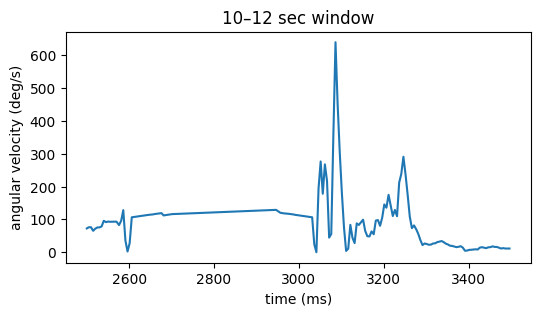

In [43]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2500) &   # 10 sec
    (df_clean["time_ms"] <= 3500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

## Outliers

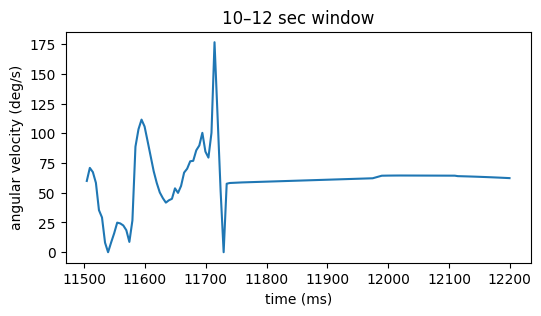

In [44]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 1) &
    (df_clean["time_ms"] >= 11500) &   # 10 sec
    (df_clean["time_ms"] <= 12200)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

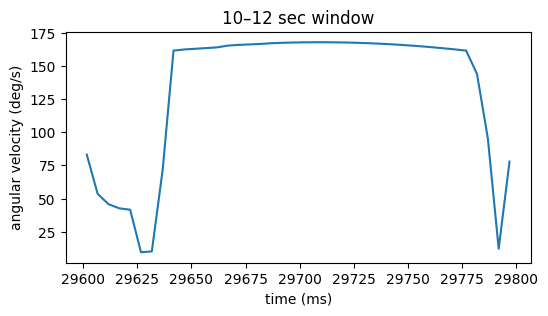

In [45]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 29600) &   # 10 sec
    (df_clean["time_ms"] <= 29800)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

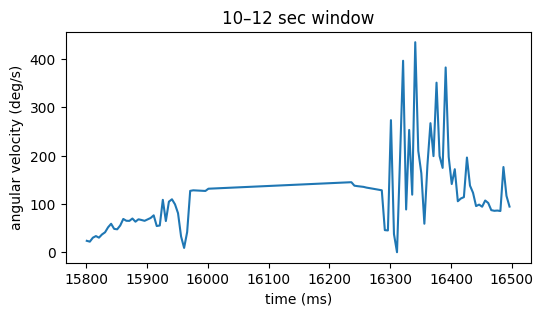

In [46]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 4) &
    (df_clean["time_ms"] >= 15800) &   # 10 sec
    (df_clean["time_ms"] <= 16500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

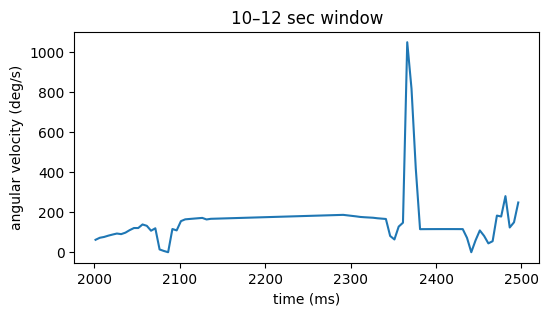

In [47]:
sub = df_clean[
    (df_clean["condition_number"] == 1) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 2000) &   # 10 sec
    (df_clean["time_ms"] <= 2500)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

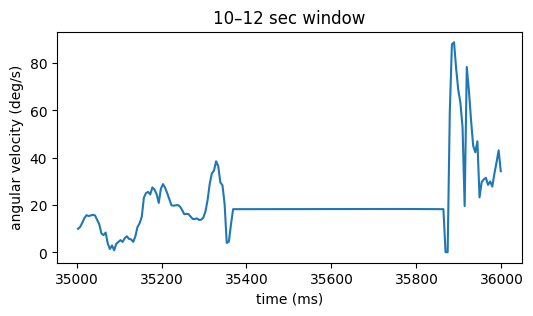

In [48]:
sub = df_clean[
    (df_clean["condition_number"] == 3) &
    (df_clean["trial_number"] == 5) &
    (df_clean["time_ms"] >= 35000) &   # 10 sec
    (df_clean["time_ms"] <= 36000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [49]:
df_clean["velocity_category"].value_counts()

KeyError: 'velocity_category'

In [41]:
df_clean["clean_gaze_forward_x"].isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
202964    False
202965    False
202966    False
202967    False
202968    False
Name: clean_gaze_forward_x, Length: 202969, dtype: bool

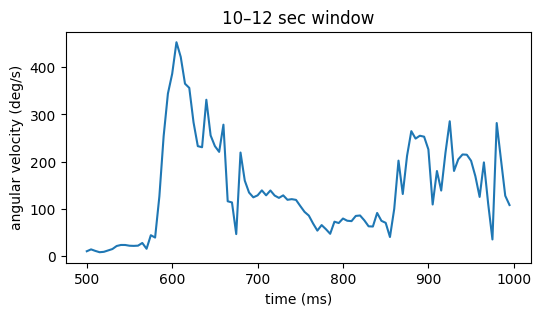

In [38]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 500) &   # 10 sec
    (df_clean["time_ms"] <= 1000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

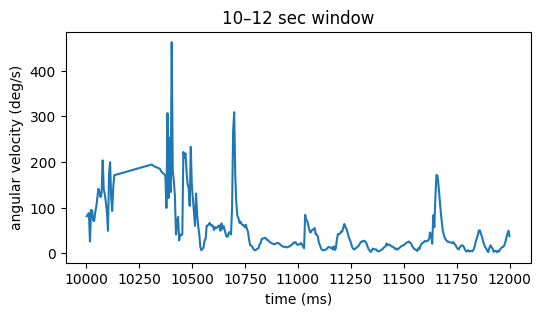

In [39]:
sub = df_clean[
    (df_clean["condition_number"] == 2) &
    (df_clean["trial_number"] == 2) &
    (df_clean["time_ms"] >= 10000) &   # 10 sec
    (df_clean["time_ms"] <= 12000)     # 12 sec
].copy()

plt.figure(figsize=(6,3))
plt.plot(sub["time_ms"], sub["angular_velocity"])
plt.xlabel("time (ms)")
plt.ylabel("angular velocity (deg/s)")
plt.title("10–12 sec window")
plt.show()

In [18]:
def add_velocity_category(df, vel_col="angular_velocity"):
    """
    Add a simple categorical label based on angular velocity.

    Categories
    ----------
    0–30 deg/s     -> fixation
    30–100 deg/s   -> pursuit
    100–200 deg/s  -> small saccade
    200–400 deg/s  -> medium saccade
    400–700 deg/s  -> large saccade
    >700 deg/s     -> outlier
    """
    df = df.copy()

    df["velocity_category"] = np.select(
        [
            df[vel_col].isna(),
            df[vel_col] < 30,
            df[vel_col] < 100,
            df[vel_col] < 200,
            df[vel_col] < 400,
            df[vel_col] < 700,
            df[vel_col] >= 700
        ],
        [
            "missing",
            "fixation",
            "pursuit",
            "small_saccade",
            "medium_saccade",
            "large_saccade",
            "outlier"
        ],
        default="missing"
    )

    df.loc[df[vel_col].isna(), "velocity_category"] = np.nan

    return df

In [62]:
df_clean = add_velocity_category(df_clean)

In [63]:
df_clean

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,is_rejected,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,False,0.013115,0.144055,0.989483,C1_T1,NaN,NaN
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,False,0.013078,0.144172,0.989466,C1_T1,1.420650,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,False,0.013039,0.144279,0.989451,C1_T1,1.307756,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,False,0.012964,0.144379,0.989438,C1_T1,0.664515,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,pursuit
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,pursuit
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,False,0.289915,-0.071516,0.954377,C3_T6,22.406689,fixation


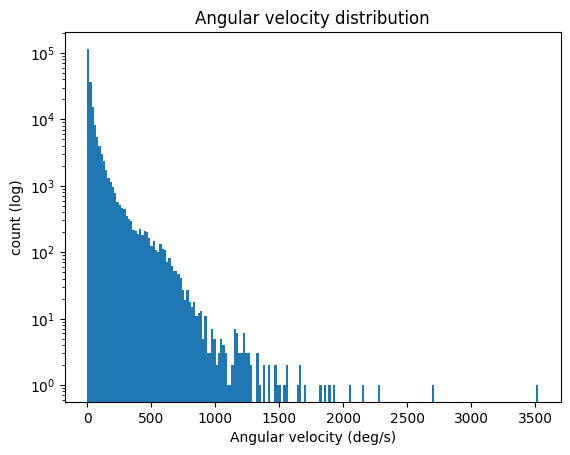

In [24]:
plt.hist(df_clean["angular_velocity"], bins=200)
plt.yscale("log")
plt.xlabel("Angular velocity (deg/s)")
plt.ylabel("count (log)")
plt.title("Angular velocity distribution")
plt.show()

In [25]:
# sort first (important)
df_tmp = df_clean.sort_values(
    ["condition_number", "trial_number", "gaze_capture_time"]
)

# compute dt in seconds
t = df_tmp["gaze_capture_time"].to_numpy(dtype=np.int64)
dt = np.diff(t) * 1e-9  # ns → s

# inspect
print("dt stats (s):")
print("mean:", dt.mean())
print("median:", np.median(dt))
print("min:", dt.min())
print("max:", dt.max())

dt stats (s):
mean: 0.012193567535769187
median: 0.0050006
min: 0.0039648
max: 651.1516063


In [31]:
df_tmp

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,good_sample,bad_sample,is_interpolated,is_rejected,clean_gaze_forward_x,clean_gaze_forward_y,clean_gaze_forward_z,segment_label,angular_velocity,velocity_category
0,1000325694741666500,1773141240816,336.4777,0.975025,584492,0.821958,Valid,0.013115,0.144055,0.989483,...,True,False,False,False,0.013115,0.144055,0.989483,C1_T1,NaN,NaN
1,1000325694746666700,1773141240816,336.4777,0.977628,584493,0.817059,Valid,0.013078,0.144172,0.989466,...,True,False,False,False,0.013078,0.144172,0.989466,C1_T1,1.420650,fixation
2,1000325694751663700,1773141240816,336.4777,0.980051,584494,0.827888,Valid,0.013039,0.144279,0.989451,...,True,False,False,False,0.013039,0.144279,0.989451,C1_T1,1.307756,fixation
3,1000325694756664500,1773141240816,336.4777,0.982777,584495,0.820999,Valid,0.013003,0.144336,0.989443,...,True,False,False,False,0.013003,0.144336,0.989443,C1_T1,0.791661,fixation
4,1000325694761666200,1773141240824,336.4866,0.985244,584496,0.822582,Valid,0.012964,0.144379,0.989437,...,True,False,False,False,0.012964,0.144379,0.989438,C1_T1,0.664515,fixation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202964,1000328169625686100,1773143715702,1593.0000,0.677271,1079278,0.281021,Valid,0.285666,-0.076886,0.955240,...,True,False,False,False,0.285666,-0.076886,0.955240,C3_T6,37.569699,pursuit
202965,1000328169630684400,1773143715702,1593.0000,0.681785,1079279,0.310471,Valid,0.287534,-0.074987,0.954831,...,True,False,False,False,0.287534,-0.074987,0.954830,C3_T6,30.886675,pursuit
202966,1000328169635683800,1773143715702,1593.0000,0.681963,1079280,0.328037,Valid,0.288786,-0.073097,0.954599,...,True,False,False,False,0.288786,-0.073097,0.954599,C3_T6,26.124483,fixation
202967,1000328169640683200,1773143715702,1593.0000,0.681368,1079281,0.382888,Valid,0.289915,-0.071516,0.954377,...,True,False,False,False,0.289915,-0.071516,0.954377,C3_T6,22.406689,fixation


In [30]:
high_vel = df_tmp["angular_velocity"] > 700

# align dt with rows (dt corresponds to index 1:)
dt_series = pd.Series(dt, index=df_tmp.index[1:])

dt_outliers = dt_series[high_vel.iloc[1:]]

print(dt_outliers.describe())

count    377.000000
mean       0.005240
std        0.001392
min        0.004985
25%        0.005000
50%        0.005001
75%        0.005002
max        0.020004
dtype: float64


# 9. Function: Adaptive MAD Threshold (at_mad)

In [125]:
def at_mad(angular_vel, th_0=200.0, min_change=1.0):
    angular_vel = np.asarray(angular_vel, dtype=float)
    angular_vel = angular_vel[np.isfinite(angular_vel)]
    angular_vel = angular_vel[angular_vel >= 0]

    threshs = []

    if angular_vel.size == 0:
        return np.nan, threshs

    while True:
        threshs.append(th_0)

        below = angular_vel[angular_vel < th_0]
        if below.size == 0:
            return np.nan, threshs

        median = np.median(below)
        mad = np.median(np.abs(below - median))

        th_1 = median + 3 * 1.486 * mad

        if abs(th_0 - th_1) > min_change:
            th_0 = th_1
        else:
            saccade_thresh = th_1
            threshs.append(saccade_thresh)
            break

    return saccade_thresh, threshs

# 10. Smoothing the Data (5-point Median Filter)

# 11. Compute Angular Velocity

In [126]:
def compute_angular_velocity(sub: pd.DataFrame) -> pd.DataFrame:
    sub = sub.sort_values("time_ms").copy()

    xyz = sub[[
        "clean_gaze_forward_x",
        "clean_gaze_forward_y",
        "clean_gaze_forward_z"
    ]].to_numpy(dtype=float)

    t = sub["time_ms"].to_numpy(dtype=float)

    ang_vel = np.full(len(sub), np.nan, dtype=float)

    for i in range(1, len(sub)):
        if not (np.all(np.isfinite(xyz[i-1])) and np.all(np.isfinite(xyz[i]))):
            continue

        dt_s = (t[i] - t[i-1]) / 1000.0
        if dt_s <= 0:
            continue

        dot = np.clip(np.dot(xyz[i-1], xyz[i]), -1.0, 1.0)
        angle_deg = np.degrees(np.arccos(dot))
        ang_vel[i] = angle_deg / dt_s

    sub["angular_velocity_deg_s"] = ang_vel
    return sub

#for the whole data segments
df = (
    df.groupby(["condition_number", "trial_number"], group_keys=False)
      .apply(compute_angular_velocity)
      .reset_index(drop=True)
)


KeyError: 'time_ms'

# 12. Smooth Angular Velocity (Savitzky–Golay)

# 13. Compute Threshold

In [20]:
vel_all = df.loc[
    ~df["is_rejected"] & df["angular_velocity_deg_s"].notna(),
    "angular_velocity_deg_s"
].to_numpy()

global_thresh, thresh_history = at_mad(vel_all, th_0=200.0)

print("Global saccade threshold:", global_thresh)
print("Threshold history:", thresh_history)



Global saccade threshold: 39.619307880636924
Threshold history: [200.0, np.float64(68.27338871684113), np.float64(50.75341044106674), np.float64(44.58470307959868), np.float64(41.72015693574237), np.float64(40.34828379140593), np.float64(39.619307880636924)]


# 14.Saccade and Fixation Classification

In [22]:
df["is_saccade"] = (
    ~df["is_rejected"] &
    df["angular_velocity_deg_s"].notna() &
    (df["angular_velocity_deg_s"] > global_thresh)
)

#df["has_valid_clean_gaze"] = df[clean_cols].notna().all(axis=1)

df["is_fixation_candidate"] = (
    ~df["is_rejected"] & 
    ~df["is_saccade"])


print("Global saccade threshold:", global_thresh)
print("Saccade samples:", int(df["is_saccade"].sum()))
print("Fixation-candidate samples:", int(df["is_fixation_candidate"].sum()))

print(df.head(100))

Global saccade threshold: 39.619307880636924
Saccade samples: 32669
Fixation-candidate samples: 84536
      gaze_capture_time  raw_timestamp  relative_to_unix_epoch_timestamp  \
0   1000668940253006100  1771488423083                          103.1286   
1   1000668940258005900  1771488423083                          103.1286   
2   1000668940263006700  1771488423083                          103.1286   
3   1000668940268007500  1771488423083                          103.1286   
4   1000668940273008900  1771488423083                          103.1286   
..                  ...            ...                               ...   
95  1000668940728066800  1771488423524                          103.5723   
96  1000668940733068800  1771488423535                          103.5828   
97  1000668940738068000  1771488423535                          103.5828   
98  1000668940743069900  1771488423545                          103.5941   
99  1000668940748078300  1771488423545                        

# 15. Correct Small Events (Minimum Duration Rules)

# 16. Define Events (Onset, Offset, Duration)

# 17. Save Outputs